1.FILE CHECK

In [2]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles in Folder:")
print(os.listdir())

Current Folder:
c:\Users\priya\OneDrive\Documents\intenship

Files in Folder:
['.git', '.vscode', 'cleaned_dataset.csv', 'day2.ipynb', 'day3.py', 'day4students.csv.py', 'day5.py', 'day6.py', 'day7.py', 'day8(seaborn).py', 'eda_report.ipynb', 'EDA__REPORT.ipynb', 'employee1.sql', 'MYSQL Local.session.sql', 'output.csv', 'student.sql', 'student10_analysis.sql', 'students.csv', 'students.xlsx', 'titanic-Dataset.csv', 'WineQT.csv']


2.DATASET LOAD

In [1]:
import pandas as pd

df = pd.read_csv("titanic-Dataset.csv")

print(df.head())

   PassengerId  Survived  Pclass       Name     Sex   Age  SibSp  Parch  \
0            1         0       3     Braund    male  22.0      1      0   
1            2         1       1    Cumings  female  38.0      1      0   
2            3         1       3  Heikkinen  female  26.0      0      0   
3            4         1       1   Futrelle  female  35.0      1      0   
4            5         0       3      Allen    male  35.0      0      0   

    Ticket   Fare Cabin Embarked  
0      A/5   7.25   C85        S  
1  PC17599  71.28  C123        C  
2  STON/O2   7.92   NaN        S  
3   113803  53.10  C123        S  
4   373450   8.05   NaN        S  


In [3]:
df.shape

(10, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  10 non-null     int64  
 1   Survived     10 non-null     int64  
 2   Pclass       10 non-null     int64  
 3   Name         10 non-null     str    
 4   Sex          10 non-null     str    
 5   Age          9 non-null      float64
 6   SibSp        10 non-null     int64  
 7   Parch        10 non-null     int64  
 8   Ticket       10 non-null     str    
 9   Fare         10 non-null     float64
 10  Cabin        4 non-null      str    
 11  Embarked     10 non-null     str    
dtypes: float64(2), int64(5), str(5)
memory usage: 1.1 KB


In [5]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            1
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          6
Embarked       0
dtype: int64

INSPECTION

In [6]:
print("Shape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nStatistics:")
print(df.describe())

Shape:
(10, 12)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  10 non-null     int64  
 1   Survived     10 non-null     int64  
 2   Pclass       10 non-null     int64  
 3   Name         10 non-null     str    
 4   Sex          10 non-null     str    
 5   Age          9 non-null      float64
 6   SibSp        10 non-null     int64  
 7   Parch        10 non-null     int64  
 8   Ticket       10 non-null     str    
 9   Fare         10 non-null     float64
 10  Cabin        4 non-null      str    
 11  Embarked     10 non-null     str    
dtypes: float64(2), int64(5), str(5)
memory usage: 1.1 KB

Statistics:
       PassengerId   Survived     Pclass        Age      SibSp      Parch  \
count     10.00000  10.000000  10.000000   9.000000  10.000000  10.000000   
mean       5.50000   0.500000   2.300000  28.111111   0.700000   0.300000

MISSING VALUES

In [7]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            1
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          6
Embarked       0
dtype: int64


CLEANING

In [8]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

df = df.drop_duplicates()

print("Cleaning Completed")

Cleaning Completed


VISUAL ANALYSIS

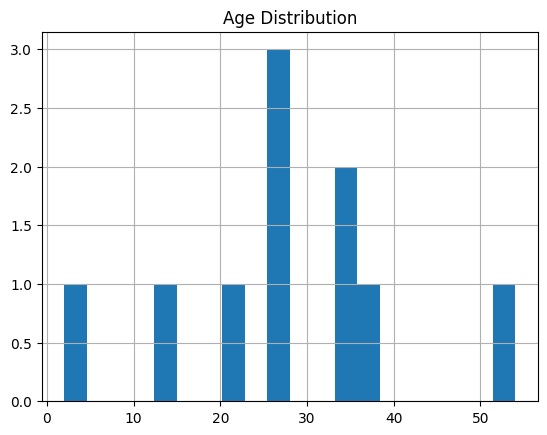

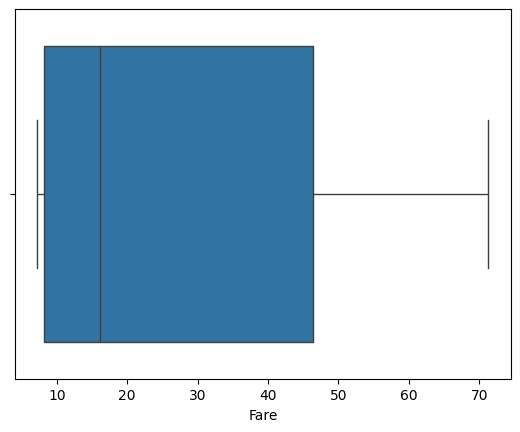

In [ ]:
#HISTOGRAM
import matplotlib.pyplot as plt

df["Age"].hist(bins=20)

plt.title("Age Distribution")
plt.show()
#SKEWNESS
df["Age"].skew()
#BOXPLOT
import seaborn as sns

sns.boxplot(x=df["Fare"])
plt.show()
#SCATTERPLOT
sns.scatterplot(
    x="Age",
    y="Fare",
    data=df
)
plt.show()
#CORRELATION HEATMAP
numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.show()

SAVE CLEAN DATASET

In [9]:
df.to_csv("cleaned_dataset.csv", index=False)

print("cleaned_dataset.csv saved successfully")

cleaned_dataset.csv saved successfully


# Insights for ML Modeling

1. High Correlations
- No extremely strong correlations observed.
- Pclass and Fare show moderate relationship.

2. Outliers
- Fare contains significant outliers.
- These may require clipping or log transformation before training.

3. Structural Changes
- Removed duplicate records.
- Filled missing values in Age, Embarked, and Cabin.
- Verified all columns contain valid values.
- Dataset is now ready for ML model training.